# Višeklasna klasifikacija pomoću višeslojnog perceptrona

In [1]:
# Import potrebnih modula /  klasa i funkcija
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import  confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt

## Učitavanje skupa podataka

U ovom zadatku koristi se **Iris dataset** iz biblioteke **scikit-learn**.  
Ovaj skup podataka se koristi za zadatke **višeklasne klasifikacije**.

📄 Dokumentaciji možete pristupiti [ovde](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html)

In [2]:
# Učitati Iris dataset i izdvojiti ulazne podatke (X) i ciljne vrednosti (y)
iris = load_iris()
X = iris.data
y = iris.target

# Prikazati osnovne informacije o dataset-u (broj uzoraka, broj atributa i nazive klasa)
print("Broj uzoraka:", X.shape[0])
print("Broj atributa:", X.shape[1])
print("Nazivi klasa:", iris.target_names)

Broj uzoraka: 150
Broj atributa: 4
Nazivi klasa: ['setosa' 'versicolor' 'virginica']


## Podela na trening i test **skupove**

In [3]:
# Podeliti podatke na trening (80%) i test (20%) skup
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Skaliranje / standardizacija podataka

In [4]:
# Standardizovati varijable
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Kreiranje modela

In [5]:
# Kreirati MLPClassifier model sa jednim skrivenim slojem od 32 neurona, maksimalnim brojem iteracija 5000 i postaviti random state
mlp = MLPClassifier(
    hidden_layer_sizes=(32,),
    max_iter=5000,
    random_state=42
)

In [6]:
# Prikazati osnovne informacije o arhitekturi mreže
print("Arhitektura mreze:")
print("Broj ulaznih neurona:", X_train.shape[1])
print("Skriveni slojevi:", mlp.hidden_layer_sizes)

Arhitektura mreze:
Broj ulaznih neurona: 4
Skriveni slojevi: (32,)


## Trening modela

In [7]:
# Istrenirati model
mlp.fit(X_train, y_train)

MLPClassifier(hidden_layer_sizes=(32,), max_iter=5000, random_state=42)

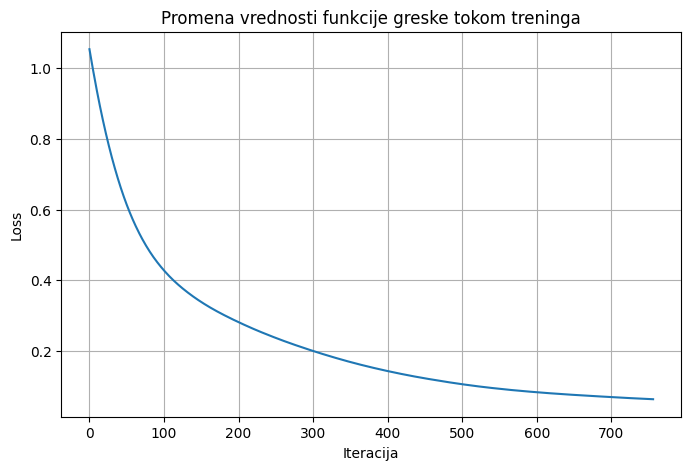

In [8]:
# Prikazati promenu vrednosti funkcije greške (loss) tokom treninga
plt.figure(figsize=(8, 5))
plt.plot(mlp.loss_curve_)
plt.xlabel("Iteracija")
plt.ylabel("Loss")
plt.title("Promena vrednosti funkcije greske tokom treninga")
plt.grid()
plt.show()

In [9]:
# Prikazati osnovne informacije o modelu nakon treninga (broj izlaza, dimenzije težina i bias-a, broj iteracija i finalni loss)
print("\nBroj izlaznih neurona:", mlp.n_outputs_)

for i, coef in enumerate(mlp.coefs_):
    print(f"Matrica tezina {i+1}: {coef.shape}")

for i, intercept in enumerate(mlp.intercepts_):
    print(f"Bias vektor {i+1}: {intercept.shape}")

print("Broj iteracija:", mlp.n_iter_)
print("Finalni loss:", mlp.loss_)


Broj izlaznih neurona: 3
Matrica tezina 1: (4, 32)
Matrica tezina 2: (32, 3)
Bias vektor 1: (32,)
Bias vektor 2: (3,)
Broj iteracija: 757
Finalni loss: 0.06308975399692926


## Kreiranje predikcija

In [10]:
# Izvršiti predikciju
y_pred = mlp.predict(X_test)
y_proba = mlp.predict_proba(X_test)

In [11]:
# Prikazati nekoliko primera predikcija
print("Primeri predikcija:")
for i in range(5):
    print(f"Uzorak {i+1}: stvarna klasa = {y_test[i]}, predikcija = {y_pred[i]}, verovatnoce = {y_proba[i]}")

Primeri predikcija:
Uzorak 1: stvarna klasa = 0, predikcija = 0, verovatnoce = [9.99543133e-01 4.53071773e-04 3.79516327e-06]
Uzorak 2: stvarna klasa = 2, predikcija = 2, verovatnoce = [0.00459446 0.23862126 0.75678428]
Uzorak 3: stvarna klasa = 1, predikcija = 1, verovatnoce = [0.0334882  0.96198742 0.00452438]
Uzorak 4: stvarna klasa = 1, predikcija = 1, verovatnoce = [0.0120876  0.98406917 0.00384323]
Uzorak 5: stvarna klasa = 0, predikcija = 0, verovatnoce = [9.99822143e-01 1.75295752e-04 2.56148303e-06]


## Evaluacija modela

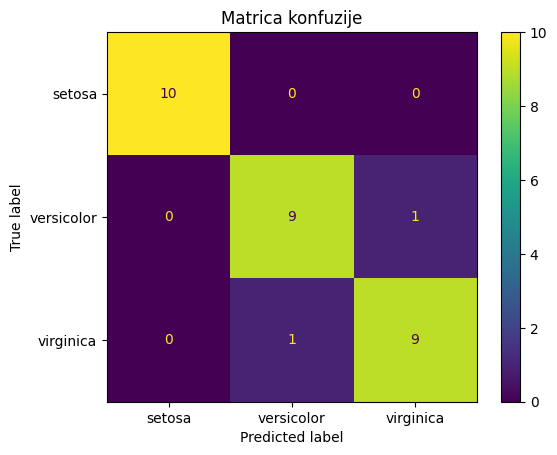

In [12]:
# Kreirati i prikazati matricu konfuzije
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)
disp.plot()
plt.title("Matrica konfuzije")
plt.show()

In [13]:
# Izračunati tačnost modela i prikazati classification report
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy * 100:.2f}%")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=iris.target_names))


Accuracy: 93.33%

Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

